# Propagation in deep water (JAX)

This notebook demonstrates underwater acoustic propagation in deep water with a Munk sound speed profile using the JAX-based solver.
For the legacy NumPy/Cython version, see [uwa_deep_water.ipynb](uwa_deep_water.ipynb).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), ".." if "uwa" not in os.getcwd() else "../..", "..", "..", "..")))
# Handle running from docs/source/notebooks or project root
for p in [".", "..", "../..", "../../..", "../../../.."]:
    full = os.path.abspath(p)
    if os.path.exists(os.path.join(full, "pywaveprop")):
        sys.path.insert(0, full)
        break


In [2]:
import jax
jax.config.update('jax_enable_x64', True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from pywaveprop.uwa_jax import (
    UWAGaussSourceModel,
    UnderwaterLayerModel,
    UnderwaterEnvironmentModel,
    uwa_forward_task,
)
from pywaveprop.uwa_utils import UWAComputationalParams
from pywaveprop.helmholtz_jax import (
    PiecewiseLinearWaveSpeedModel,
    ConstWaveSpeedModel,
)

## Munk sound speed profile

The canonical Munk profile has a sound channel axis at ~1300 m depth.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


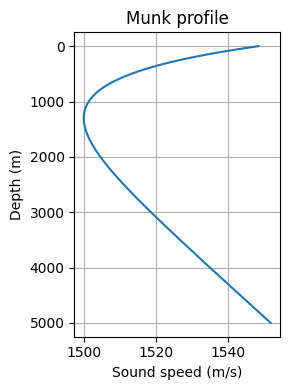

In [3]:
def munk_profile(z, ref_speed=1500, ref_depth=1300, eps=0.00737):
    z_ = 2 * (z - ref_depth) / ref_depth
    return ref_speed * (1 + eps * (z_ - 1 + np.exp(-z_)))

# Create piecewise-linear approximation for the JAX model
z_ssp = jnp.linspace(0, 5000, 200)
c_ssp = jnp.array(munk_profile(np.asarray(z_ssp)))

# Plot the profile
plt.figure(figsize=(3, 4))
plt.plot(np.asarray(c_ssp), np.asarray(z_ssp))
plt.gca().invert_yaxis()
plt.xlabel('Sound speed (m/s)')
plt.ylabel('Depth (m)')
plt.title('Munk profile')
plt.grid(True)
plt.tight_layout()
plt.show()

## Preparing environment

In [4]:
max_range_m = 200e3

munk_ssp = PiecewiseLinearWaveSpeedModel(z_grid_m=z_ssp, sound_speed=c_ssp)

env = UnderwaterEnvironmentModel(layers=[
    UnderwaterLayerModel(
        height_m=5000,
        sound_speed_profile_m_s=munk_ssp,
        density=1.0,
    ),
    UnderwaterLayerModel(
        height_m=500,
        sound_speed_profile_m_s=ConstWaveSpeedModel(c0=1700),
        density=1.5,
        attenuation_dm_lambda=0.5,
    ),
])

## Preparing source

In [5]:
src = UWAGaussSourceModel(
    freq_hz=50,
    depth_m=100,
    beam_width_deg=3,
    elevation_angle_deg=0,
    multiplier=5,
)

## Computing the acoustic pressure field

In [6]:
params = UWAComputationalParams(
    max_range_m=max_range_m,
    max_depth_m=5500,
    dx_m=100,
    dz_m=5,
)

field = uwa_forward_task(src, env, params)

k_min: 0.1848073234242697, k_max: 0.2094394275000087
rational_approx_order: (3, 4), beta: 0.19083321745288317, dx: 50.0, dz: 5.0


## Visualising results

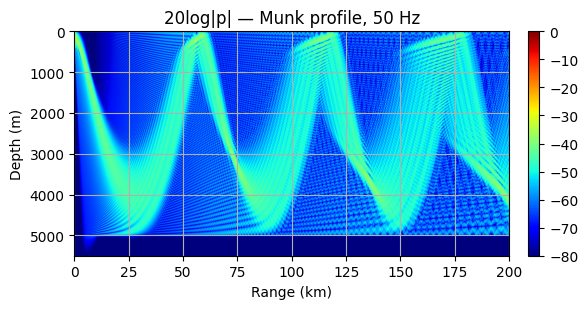

In [7]:
data = 20 * np.log10(np.abs(np.asarray(field.field)) + 1e-16).real
extent = [field.x_grid[0]*1e-3, field.x_grid[-1]*1e-3,
          field.z_grid[-1], field.z_grid[0]]

plt.figure(figsize=(6, 3.2))
plt.imshow(data.T, extent=extent,
           norm=Normalize(-80, 0), aspect='auto', cmap='jet')
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('20log|p| — Munk profile, 50 Hz')
plt.xlabel('Range (km)')
plt.ylabel('Depth (m)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Irregular bottom

Gaussian seamount centered at 100 km range, rising from 5000 m to 2000 m.

In [8]:
import math as fm

# Bathymetry: Gaussian seamount at 100 km, bottom rises from 5000 m to 2000 m
x_bathy = jnp.linspace(0, max_range_m, 500)
depth_bathy = 5000 - 3000 * jnp.exp(-(x_bathy - 100e3)**2 / 1e9)

# Bathymetry specifies the bottom depth; the propagator zeros the field below it
from pywaveprop.helmholtz_jax import PiecewiseLinearTerrainModel

terrain = PiecewiseLinearTerrainModel(
    x_grid_m=x_bathy,
    height=depth_bathy,
)

env_irreg = UnderwaterEnvironmentModel(
    layers=[
        UnderwaterLayerModel(
            height_m=5000,
            sound_speed_profile_m_s=munk_ssp,
            density=1.0,
        ),
        UnderwaterLayerModel(
            height_m=500,
            sound_speed_profile_m_s=ConstWaveSpeedModel(c0=1700),
            density=1.5,
            attenuation_dm_lambda=0.5,
        ),
    ],
    bathymetry=terrain,
)


In [9]:
field_irreg = uwa_forward_task(src, env_irreg, params)


k_min: 0.1848073234242697, k_max: 0.2094394275000087
rational_approx_order: (3, 4), beta: 0.19083321745288317, dx: 50.0, dz: 5.0


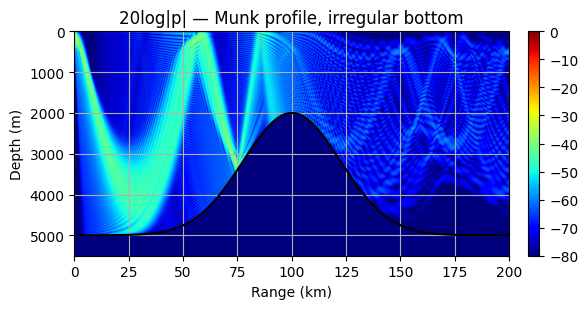

In [10]:
data_irreg = 20 * np.log10(np.abs(np.asarray(field_irreg.field)) + 1e-16).real
extent = [field_irreg.x_grid[0]*1e-3, field_irreg.x_grid[-1]*1e-3,
          field_irreg.z_grid[-1], field_irreg.z_grid[0]]

plt.figure(figsize=(6, 3.2))
plt.imshow(data_irreg.T, extent=extent,
           norm=Normalize(-80, 0), aspect="auto", cmap="jet")
plt.colorbar(fraction=0.046, pad=0.04)

# Plot bathymetry line
plt.plot(np.asarray(x_bathy)*1e-3, np.asarray(depth_bathy), "k", linewidth=1.5)

plt.title("20log|p| — Munk profile, irregular bottom")
plt.xlabel("Range (km)")
plt.ylabel("Depth (m)")
plt.grid(True)
plt.tight_layout()
plt.show()
